STEP 1 ▸ Loading dataset
  ✔ Dataset loaded  →  37,249 rows, 2 columns
  Columns detected : ['clean_comment', 'category']

STEP 2 ▸ Auto-detecting text and target columns
  Text   column : 'clean_comment'
  Target column : 'category'

STEP 3 ▸ Exploratory Data Analysis

  Class distribution:
category
 1    15830
 0    13142
-1     8277


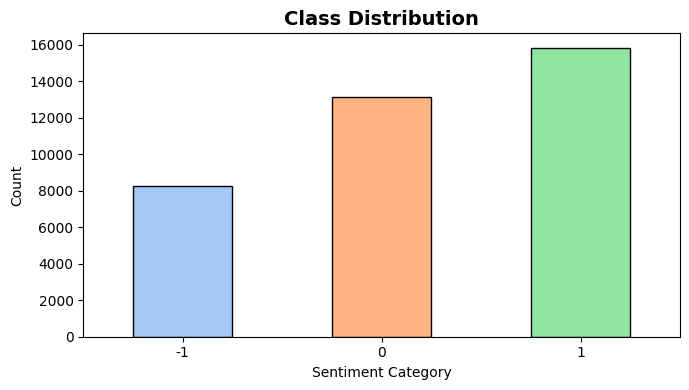

  ✔ Class-distribution chart saved → class_distribution.png

STEP 4 ▸ Data Preprocessing
  Missing / empty rows removed : 221
  Cleaning text  (this may take ~30 s for large corpora)…
  ✔ Text cleaning done in 0.9s
  Post-cleaning empty rows removed : 199

  Sample cleaned texts:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

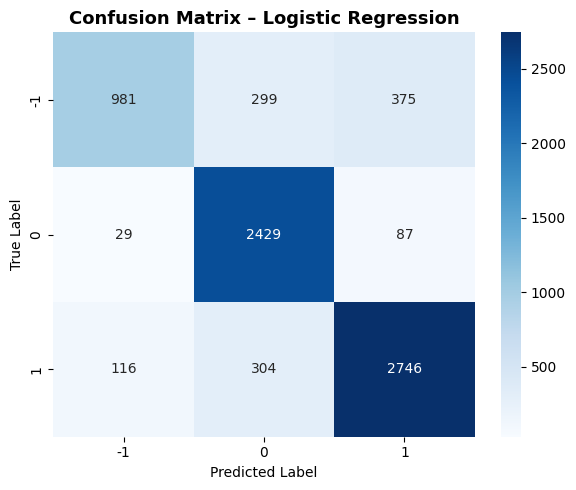

  ✔ Confusion matrix saved → confusion_matrix_lr.png

STEP 8 ▸ Training Model 2 : Random Forest Classifier
  ✔ Random Forest trained in 194.5s

  ──────────────────────────────────────────────────
  Results for : Random Forest
  ──────────────────────────────────────────────────
    Accuracy    : 0.8095
    Precision   : 0.8209
    Recall      : 0.8095
    F1-Score    : 0.7944

  Classification Report:

              precision    recall  f1-score   support

          -1       0.89      0.43      0.58      1655
           0       0.85      0.94      0.89      2545
           1       0.76      0.90      0.83      3166

    accuracy                           0.81      7366
   macro avg       0.83      0.76      0.77      7366
weighted avg       0.82      0.81      0.79      7366



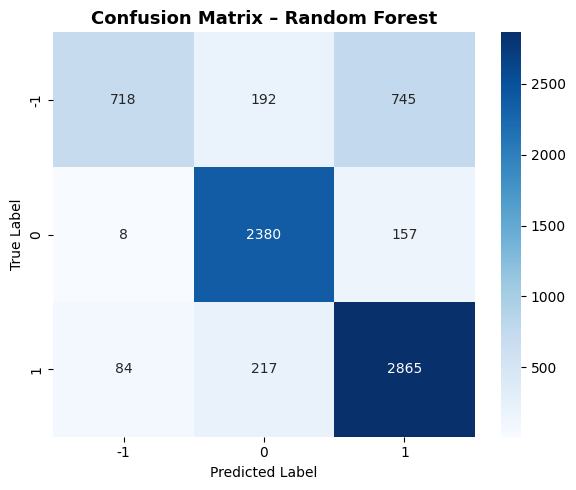

  ✔ Confusion matrix saved → confusion_matrix_rf.png

STEP 9 ▸ Model Performance Comparison

                      Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression    0.8357     0.8405  0.8357    0.8298
Random Forest          0.8095     0.8209  0.8095    0.7944

  Best model per metric:
    Accuracy    : Logistic Regression  (0.8357)
    Precision   : Logistic Regression  (0.8405)
    Recall      : Logistic Regression  (0.8357)
    F1-Score    : Logistic Regression  (0.8298)


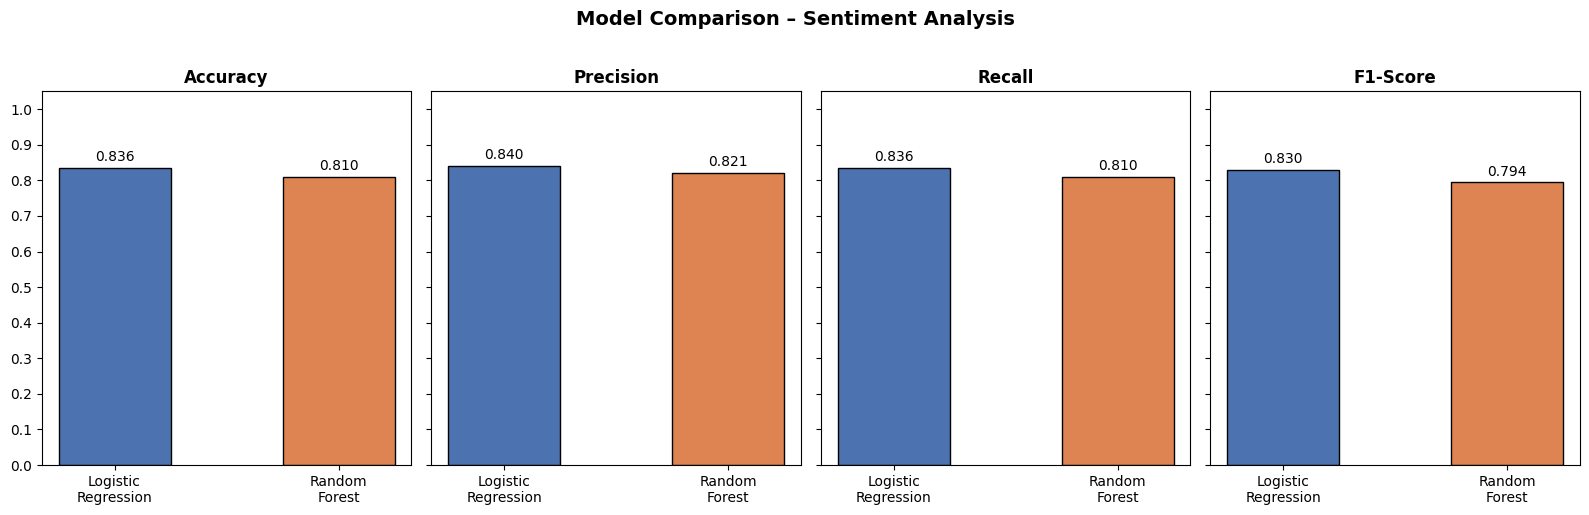

  ✔ Comparison chart saved → model_comparison.png

STEP 10 ▸ Final Verdict

  🏆  WINNER → Logistic Regression
      Weighted F1 : 0.8298  vs  0.7944 (Random Forest)

  Saved artefacts:
    • class_distribution.png
    • confusion_matrix_lr.png
    • confusion_matrix_rf.png
    • model_comparison.png

  Pipeline complete. ✔


In [ ]:
# ============================================================
#   SENTIMENT ANALYSIS PIPELINE
#   Models: Logistic Regression & Random Forest Classifier
#   Compatible with: Google Colab (no modifications needed)
# ============================================================

# ── 0. Install / import dependencies ────────────────────────
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

# Ensure nltk data is available
import nltk
nltk.download("stopwords", quiet=True)
nltk.download("punkt",     quiet=True)

import re
import time
import warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords

from sklearn.model_selection  import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (accuracy_score, precision_score,
                                      recall_score, f1_score,
                                      confusion_matrix, classification_report)

# ── 1. Load dataset ─────────────────────────────────────────
print("=" * 60)
print("STEP 1 ▸ Loading dataset")
print("=" * 60)

# ---- Google Colab: upload file interactively ---------------
#   Uncomment the block below if running on Colab and you want
#   to upload the CSV through the Colab file picker:
#
# from google.colab import files
# uploaded = files.upload()
# import io
# FILE_PATH = io.BytesIO(list(uploaded.values())[0])
#
# ---- OR: mount Google Drive and point to your file ---------
# from google.colab import drive
# drive.mount('/content/drive')
# FILE_PATH = '/content/drive/MyDrive/Reddit_Data.csv'
#
# ---- Default: file already in the working directory --------
FILE_PATH = "/content/Reddit_Data.csv"   # <-- change path if needed

df = pd.read_csv(FILE_PATH)

print(f"  ✔ Dataset loaded  →  {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"  Columns detected : {list(df.columns)}\n")

# ── 2. Auto-detect text & target columns ────────────────────
print("=" * 60)
print("STEP 2 ▸ Auto-detecting text and target columns")
print("=" * 60)

def detect_columns(dataframe):
    """Heuristically identify the text column and the label column."""
    text_col   = None
    target_col = None

    for col in dataframe.columns:
        if dataframe[col].dtype == object:
            avg_len = dataframe[col].dropna().astype(str).apply(len).mean()
            if avg_len > 20 and text_col is None:
                text_col = col
        else:
            if target_col is None:
                target_col = col

    # Fallbacks – use positional assignment
    if text_col is None:
        text_col   = dataframe.select_dtypes(include="object").columns[0]
    if target_col is None:
        target_col = dataframe.select_dtypes(exclude="object").columns[0]

    return text_col, target_col

TEXT_COL, TARGET_COL = detect_columns(df)
print(f"  Text   column : '{TEXT_COL}'")
print(f"  Target column : '{TARGET_COL}'\n")

# ── 3. Exploratory data overview ────────────────────────────
print("=" * 60)
print("STEP 3 ▸ Exploratory Data Analysis")
print("=" * 60)

print("\n  Class distribution:")
print(df[TARGET_COL].value_counts().to_string())

# Class-distribution bar chart
fig, ax = plt.subplots(figsize=(7, 4))
df[TARGET_COL].value_counts().sort_index().plot(
    kind="bar", ax=ax, color=sns.color_palette("pastel"), edgecolor="black"
)
ax.set_title("Class Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Sentiment Category")
ax.set_ylabel("Count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()
print("  ✔ Class-distribution chart saved → class_distribution.png\n")

# ── 4. Data Preprocessing ───────────────────────────────────
print("=" * 60)
print("STEP 4 ▸ Data Preprocessing")
print("=" * 60)

# 4-a  Drop missing values
before = len(df)
df.dropna(subset=[TEXT_COL, TARGET_COL], inplace=True)
df[TEXT_COL] = df[TEXT_COL].astype(str).str.strip()
df = df[df[TEXT_COL] != ""]
print(f"  Missing / empty rows removed : {before - len(df):,}")

# 4-b  Text cleaning function
STOP_WORDS = set(stopwords.words("english"))

def clean_text(text: str) -> str:
    """
    Pipeline:
      1. Lowercase
      2. Remove URLs
      3. Remove HTML tags
      4. Remove non-alphabetic characters (keep spaces)
      5. Remove extra whitespace
      6. Remove stopwords
    """
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)          # URLs
    text = re.sub(r"<[^>]+>", " ", text)                  # HTML
    text = re.sub(r"[^a-z\s]", " ", text)                 # punctuation / numbers
    text = re.sub(r"\s+", " ", text).strip()              # extra spaces
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 1]
    return " ".join(tokens)

print("  Cleaning text  (this may take ~30 s for large corpora)…", flush=True)
t0 = time.time()
df["clean_text"] = df[TEXT_COL].apply(clean_text)
print(f"  ✔ Text cleaning done in {time.time()-t0:.1f}s")

# Drop rows that became empty after cleaning
before = len(df)
df = df[df["clean_text"].str.strip() != ""]
print(f"  Post-cleaning empty rows removed : {before - len(df):,}\n")

# 4-c  Show a few cleaned samples
print("  Sample cleaned texts:")
print(df[["clean_text", TARGET_COL]].head(5).to_string(index=False))
print()

# ── 5. TF-IDF Vectorization ─────────────────────────────────
print("=" * 60)
print("STEP 5 ▸ TF-IDF Vectorization")
print("=" * 60)

X = df["clean_text"]
y = df[TARGET_COL]

tfidf = TfidfVectorizer(
    max_features=20_000,   # top 20 k tokens
    ngram_range=(1, 2),    # unigrams + bigrams
    sublinear_tf=True      # apply log(1+tf) scaling
)

X_vec = tfidf.fit_transform(X)
print(f"  ✔ TF-IDF matrix shape : {X_vec.shape}")
print(f"  Vocabulary size       : {len(tfidf.vocabulary_):,}\n")

# ── 6. Train / Test Split ───────────────────────────────────
print("=" * 60)
print("STEP 6 ▸ Train / Test Split  (80 % train | 20 % test)")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.20, random_state=42, stratify=y
)
print(f"  Train samples : {X_train.shape[0]:,}")
print(f"  Test  samples : {X_test.shape[0]:,}\n")

# ── 7. Helper – evaluation ──────────────────────────────────
def evaluate_model(name, y_true, y_pred, labels):
    """Compute and print all evaluation metrics; return a summary dict."""
    avg = "weighted"
    metrics = {
        "Model"    : name,
        "Accuracy" : accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average=avg, zero_division=0),
        "Recall"   : recall_score(   y_true, y_pred, average=avg, zero_division=0),
        "F1-Score" : f1_score(        y_true, y_pred, average=avg, zero_division=0),
    }
    print(f"\n  {'─'*50}")
    print(f"  Results for : {name}")
    print(f"  {'─'*50}")
    for k, v in metrics.items():
        if k != "Model":
            print(f"    {k:<12}: {v:.4f}")
    print(f"\n  Classification Report:\n")
    print(classification_report(y_true, y_pred, zero_division=0))
    return metrics


def plot_confusion_matrix(name, y_true, y_pred, labels, filename):
    """Plot and save a labelled confusion matrix heatmap."""
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(max(6, len(labels)), max(5, len(labels)-1)))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=labels, yticklabels=labels, ax=ax
    )
    ax.set_title(f"Confusion Matrix – {name}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()
    print(f"  ✔ Confusion matrix saved → {filename}\n")

CLASS_LABELS = sorted(y.unique())

# ── 8. Model 1 – Logistic Regression ────────────────────────
print("=" * 60)
print("STEP 7 ▸ Training Model 1 : Logistic Regression")
print("=" * 60)

lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver="lbfgs",
    multi_class="auto",
    random_state=42,
    n_jobs=-1
)

t0 = time.time()
lr_model.fit(X_train, y_train)
print(f"  ✔ Logistic Regression trained in {time.time()-t0:.1f}s")

y_pred_lr  = lr_model.predict(X_test)
metrics_lr = evaluate_model("Logistic Regression", y_test, y_pred_lr, CLASS_LABELS)
plot_confusion_matrix(
    "Logistic Regression", y_test, y_pred_lr,
    CLASS_LABELS, "confusion_matrix_lr.png"
)

# ── 9. Model 2 – Random Forest ──────────────────────────────
print("=" * 60)
print("STEP 8 ▸ Training Model 2 : Random Forest Classifier")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

t0 = time.time()
rf_model.fit(X_train, y_train)
print(f"  ✔ Random Forest trained in {time.time()-t0:.1f}s")

y_pred_rf  = rf_model.predict(X_test)
metrics_rf = evaluate_model("Random Forest", y_test, y_pred_rf, CLASS_LABELS)
plot_confusion_matrix(
    "Random Forest", y_test, y_pred_rf,
    CLASS_LABELS, "confusion_matrix_rf.png"
)

# ── 10. Side-by-side Model Comparison ───────────────────────
print("=" * 60)
print("STEP 9 ▸ Model Performance Comparison")
print("=" * 60)

comparison_df = pd.DataFrame([metrics_lr, metrics_rf]).set_index("Model")
print("\n", comparison_df.round(4).to_string())

# Determine winner per metric
print("\n  Best model per metric:")
for col in comparison_df.columns:
    winner = comparison_df[col].idxmax()
    print(f"    {col:<12}: {winner}  ({comparison_df.loc[winner, col]:.4f})")

# Bar-chart comparison
metric_cols = ["Accuracy", "Precision", "Recall", "F1-Score"]
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
palette = ["#4C72B0", "#DD8452"]

for ax, metric in zip(axes, metric_cols):
    vals   = [metrics_lr[metric], metrics_rf[metric]]
    models = ["Logistic\nRegression", "Random\nForest"]
    bars = ax.bar(models, vals, color=palette, edgecolor="black", width=0.5)
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=10
        )

fig.suptitle("Model Comparison – Sentiment Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("  ✔ Comparison chart saved → model_comparison.png\n")

# ── 11. Final Verdict ────────────────────────────────────────
print("=" * 60)
print("STEP 10 ▸ Final Verdict")
print("=" * 60)

f1_lr = metrics_lr["F1-Score"]
f1_rf = metrics_rf["F1-Score"]

if f1_lr > f1_rf:
    print(f"\n  🏆  WINNER → Logistic Regression")
    print(f"      Weighted F1 : {f1_lr:.4f}  vs  {f1_rf:.4f} (Random Forest)")
elif f1_rf > f1_lr:
    print(f"\n  🏆  WINNER → Random Forest")
    print(f"      Weighted F1 : {f1_rf:.4f}  vs  {f1_lr:.4f} (Logistic Regression)")
else:
    print("\n  🤝  TIE – both models achieved the same weighted F1-score.")

print("\n  Saved artefacts:")
print("    • class_distribution.png")
print("    • confusion_matrix_lr.png")
print("    • confusion_matrix_rf.png")
print("    • model_comparison.png")
print("\n  Pipeline complete. ✔")
print("=" * 60)

TensorFlow version : 2.19.0
GPU available       : False

STEP 1 ▸ Loading Dataset
  ✔ Loaded → 37,249 rows × 2 columns
  Columns : ['clean_comment', 'category']

STEP 2 ▸ Auto-detecting Text and Target Columns
  Text   column → 'clean_comment'
  Target column → 'category'
  Classes detected  : [np.int64(-1), np.int64(0), np.int64(1)]
  Number of classes : 3  → multi-class (softmax)

STEP 3 ▸ Exploratory Data Analysis

  Class distribution:
category
-1     8277
 0    13142
 1    15830


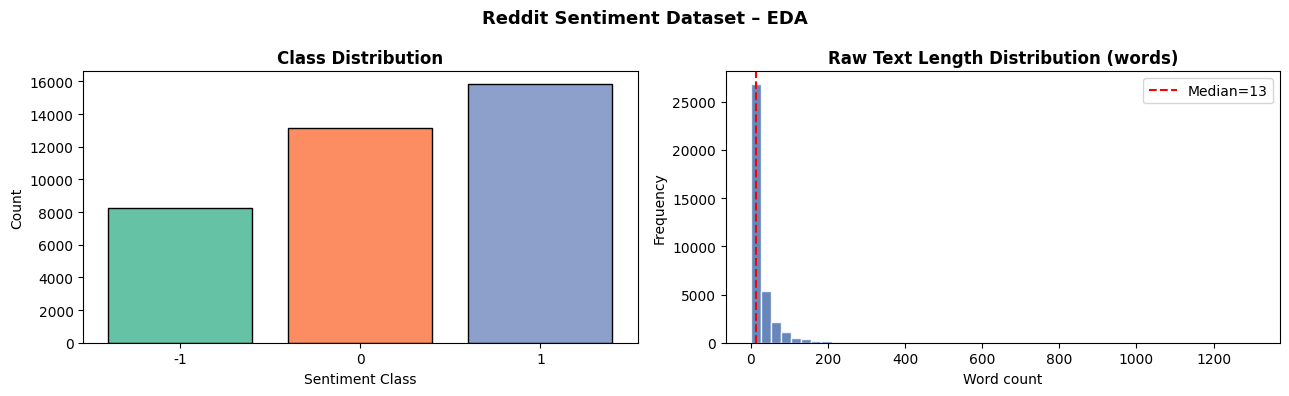

  ✔ EDA chart saved → eda_overview.png

STEP 4 ▸ Text Preprocessing
  Rows removed (missing/empty) : 221
  Cleaning text…
  ✔ Done in 0.9s
  Rows removed (empty after cleaning) : 199
  Final dataset size : 36,829

STEP 5 ▸ Encoding Labels
  Label mapping : {np.int64(-1): 0, np.int64(0): 1, np.int64(1): 2}
  Loss function  : categorical_crossentropy
  Output units   : 3  |  Activation : softmax

STEP 6 ▸ Train / Test Split  (80 % | 20 %)
  Train : 29,463  |  Test : 7,366

STEP 7 ▸ Keras Tokenization & Sequence Padding
  Vocabulary size (fitted) : 45,306
  Vocabulary cap (VOCAB_SIZE) : 30,000
  Max sequence length : 100
  X_train shape : (29463, 100)
  X_test  shape : (7366, 100)

STEP 8 ▸ Building CNN Architecture


Model: "Sentiment_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling1D)        │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_maxpool                  │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


STEP 9 ▸ Training the CNN Model
Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 52s 241ms/step - accuracy: 0.4555 - loss: 1.6199 - val_accuracy: 0.3579 - val_loss: 1.0919 - learning_rate: 0.0010
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 49s 252ms/step - accuracy: 0.5727 - loss: 0.9432 - val_accuracy: 0.4448 - val_loss: 1.0344 - learning_rate: 0.0010
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 81s 246ms/step - accuracy: 0.7345 - loss: 0.6230 - val_accuracy: 0.5516 - val_loss: 0.9669 - learning_rate: 0.0010
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 81s 243ms/step - accuracy: 0.8651 - loss: 0.3956 - val_accuracy: 0.8419 - val_loss: 0.4896 - learning_rate: 0.0010
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 47s 242ms/step - accuracy: 0.9262 - loss: 0.2542 - val_accuracy: 0.8373 - val_loss: 0.6400 - learning_rate: 0.0010
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9550 - loss: 0.1801
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
196/196 ━━━━━━━━━━━━━━━━━━━━

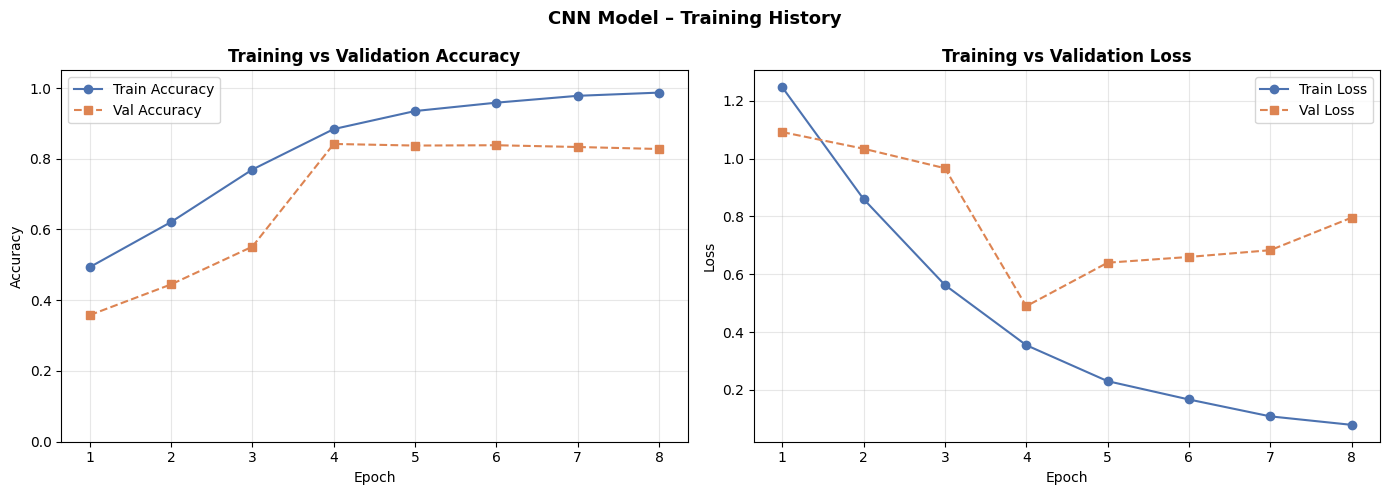

  ✔ Training history saved → cnn_training_history.png

STEP 11 ▸ Evaluating CNN on Test Set
  Test Loss     : 0.5017
  Test Accuracy : 0.8341

  ──────────────────────────────────────────────────────
  CNN Performance Metrics
  ──────────────────────────────────────────────────────
    Accuracy    : 0.8341
    Precision   : 0.8351
    Recall      : 0.8341
    F1-Score    : 0.8304

  Classification Report:

              precision    recall  f1-score   support

          -1       0.80      0.62      0.70      1655
           0       0.90      0.88      0.89      2545
           1       0.80      0.91      0.85      3166

    accuracy                           0.83      7366
   macro avg       0.83      0.80      0.81      7366
weighted avg       0.84      0.83      0.83      7366


STEP 12 ▸ Confusion Matrix


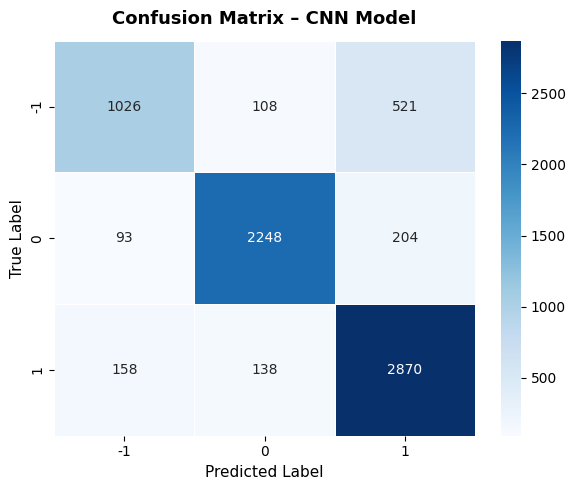

  ✔ Confusion matrix saved → confusion_matrix_cnn.png

STEP 13 ▸ Comparison with Logistic Regression & Random Forest

  ── Known scores (this run) ──────────────────────────────
                     Accuracy  Precision    Recall  F1-Score
Model                                                       
CNN                  0.834103   0.835078  0.834103  0.830426
Logistic Regression       NaN        NaN       NaN       NaN
Random Forest             NaN        NaN       NaN       NaN


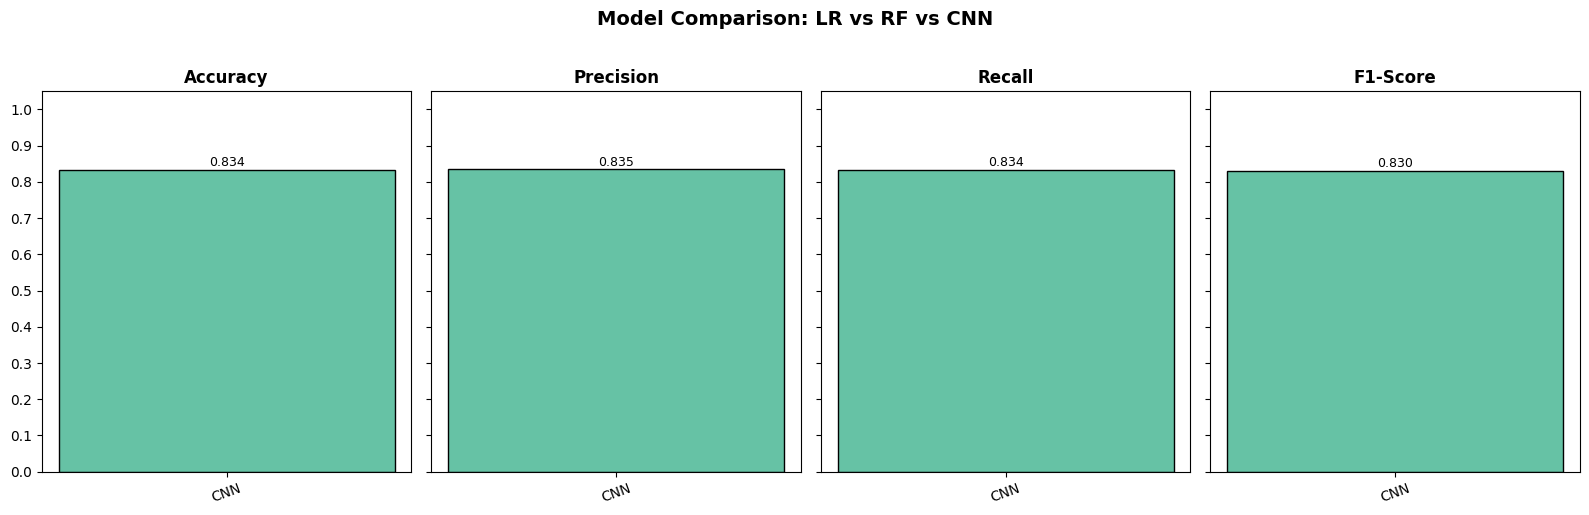

  ✔ Full comparison chart saved → model_comparison_all.png

STEP 14 ▸ CNN Performance Summary

  ┌─────────────────────────────────────┐
  │   CNN Sentiment Classifier Results  │
  ├─────────────────┬───────────────────┤
  │ Accuracy        │  0.8341            │
  │ Precision       │  0.8351            │
  │ Recall          │  0.8341            │
  │ F1-Score        │  0.8304            │
  │ Training time   │  522.8s               │
  │ Epochs ran      │  8                  │
  └─────────────────┴───────────────────┘

  Saved artefacts:
    • eda_overview.png
    • cnn_training_history.png
    • confusion_matrix_cnn.png
    • model_comparison_all.png  (if previous scores were provided)

  To compare with LR / RF, either:
  1. Run both scripts in the same Colab session and set:
     PREV_MODELS = [metrics_lr, metrics_rf]  (Step 13)
  2. Or manually paste the accuracy / F1 values into PREV_MODELS.

  Pipeline complete. ✔


In [2]:
# ============================================================
#   SENTIMENT ANALYSIS — CNN DEEP LEARNING PIPELINE
#   Model  : 1-D Convolutional Neural Network (Keras/TF)
#   Dataset: Reddit_Data.csv
#   Compatible with: Google Colab (no modifications needed)
# ============================================================

# ── 0. Seed everything for reproducibility ──────────────────
import os, random, warnings
warnings.filterwarnings("ignore")

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)

import numpy as np
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

# ── 1. Standard imports ─────────────────────────────────────
import re
import time

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import LabelEncoder
from sklearn.metrics          import (accuracy_score, precision_score,
                                      recall_score, f1_score,
                                      confusion_matrix, classification_report)

from tensorflow.keras.preprocessing.text     import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models                 import Sequential
from tensorflow.keras.layers                 import (Embedding, Conv1D,
                                                      GlobalMaxPooling1D,
                                                      MaxPooling1D, Dense,
                                                      Dropout, BatchNormalization)
from tensorflow.keras.callbacks              import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers          import l2

print("TensorFlow version :", tf.__version__)
print("GPU available       :", bool(tf.config.list_physical_devices("GPU")))

# ══════════════════════════════════════════════════════════════
# STEP 1 ▸ Load Dataset
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("STEP 1 ▸ Loading Dataset")
print("=" * 65)

# ── Colab upload options (uncomment ONE block as needed) ─────
#
# OPTION A – interactive file picker:
# from google.colab import files
# uploaded = files.upload()
# import io
# FILE_PATH = io.BytesIO(list(uploaded.values())[0])
#
# OPTION B – Google Drive:
# from google.colab import drive
# drive.mount('/content/drive')
# FILE_PATH = '/content/drive/MyDrive/Reddit_Data.csv'
#
# OPTION C – file already in Colab working dir (default):
FILE_PATH = "/content/Reddit_Data.csv"   # <-- adjust path if needed

df = pd.read_csv(FILE_PATH)
print(f"  ✔ Loaded → {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Columns : {list(df.columns)}")

# ══════════════════════════════════════════════════════════════
# STEP 2 ▸ Auto-detect Text & Target Columns
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("STEP 2 ▸ Auto-detecting Text and Target Columns")
print("=" * 65)

def detect_columns(dataframe):
    """Heuristically find the text column and label column."""
    text_col   = None
    target_col = None
    for col in dataframe.columns:
        if dataframe[col].dtype == object:
            avg_len = dataframe[col].dropna().astype(str).apply(len).mean()
            if avg_len > 20 and text_col is None:
                text_col = col
        elif target_col is None:
            target_col = col
    if text_col   is None:
        text_col   = dataframe.select_dtypes(include="object").columns[0]
    if target_col is None:
        target_col = dataframe.select_dtypes(exclude="object").columns[0]
    return text_col, target_col

TEXT_COL, TARGET_COL = detect_columns(df)
print(f"  Text   column → '{TEXT_COL}'")
print(f"  Target column → '{TARGET_COL}'")

NUM_CLASSES = df[TARGET_COL].nunique()
print(f"  Classes detected  : {sorted(df[TARGET_COL].unique())}")
print(f"  Number of classes : {NUM_CLASSES}  → "
      f"{'binary (sigmoid)' if NUM_CLASSES == 2 else 'multi-class (softmax)'}")

# ══════════════════════════════════════════════════════════════
# STEP 3 ▸ Exploratory Data Analysis
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("STEP 3 ▸ Exploratory Data Analysis")
print("=" * 65)

print("\n  Class distribution:")
print(df[TARGET_COL].value_counts().sort_index().to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Class distribution
counts = df[TARGET_COL].value_counts().sort_index()
axes[0].bar(counts.index.astype(str), counts.values,
            color=sns.color_palette("Set2", len(counts)), edgecolor="black")
axes[0].set_title("Class Distribution", fontweight="bold")
axes[0].set_xlabel("Sentiment Class"); axes[0].set_ylabel("Count")

# Text-length distribution (raw)
df["_txt_len"] = df[TEXT_COL].astype(str).apply(lambda x: len(x.split()))
axes[1].hist(df["_txt_len"], bins=50,
             color="#4C72B0", edgecolor="white", alpha=0.85)
axes[1].set_title("Raw Text Length Distribution (words)", fontweight="bold")
axes[1].set_xlabel("Word count"); axes[1].set_ylabel("Frequency")
axes[1].axvline(df["_txt_len"].median(), color="red",
                linestyle="--", label=f"Median={df['_txt_len'].median():.0f}")
axes[1].legend()

plt.suptitle("Reddit Sentiment Dataset – EDA", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("  ✔ EDA chart saved → eda_overview.png")

# ══════════════════════════════════════════════════════════════
# STEP 4 ▸ Text Preprocessing
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("STEP 4 ▸ Text Preprocessing")
print("=" * 65)

# 4-a Drop missing / empty rows
before = len(df)
df.dropna(subset=[TEXT_COL, TARGET_COL], inplace=True)
df[TEXT_COL] = df[TEXT_COL].astype(str).str.strip()
df = df[df[TEXT_COL] != ""]
print(f"  Rows removed (missing/empty) : {before - len(df):,}")

STOP_WORDS = set(stopwords.words("english"))

def clean_text(text: str) -> str:
    """
    Cleaning pipeline:
      1. Lowercase
      2. Strip URLs & HTML tags
      3. Keep only alphabetic characters
      4. Collapse whitespace
      5. Remove single-char tokens & stopwords
    """
    text = text.lower()
    text = re.sub(r"http\S+|www\S+",  " ", text)   # URLs
    text = re.sub(r"<[^>]+>",         " ", text)   # HTML
    text = re.sub(r"[^a-z\s]",        " ", text)   # punct / digits
    text = re.sub(r"\s+",             " ", text).strip()
    tokens = [t for t in text.split()
              if t not in STOP_WORDS and len(t) > 1]
    return " ".join(tokens)

print("  Cleaning text…", flush=True)
t0 = time.time()
df["clean_text"] = df[TEXT_COL].apply(clean_text)
print(f"  ✔ Done in {time.time()-t0:.1f}s")

before = len(df)
df = df[df["clean_text"].str.strip() != ""]
print(f"  Rows removed (empty after cleaning) : {before - len(df):,}")
print(f"  Final dataset size : {len(df):,}")

# ══════════════════════════════════════════════════════════════
# STEP 5 ▸ Encode Labels
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("STEP 5 ▸ Encoding Labels")
print("=" * 65)

le = LabelEncoder()
y_encoded = le.fit_transform(df[TARGET_COL])
CLASS_NAMES = le.classes_
print(f"  Label mapping : { {c: i for i, c in enumerate(CLASS_NAMES)} }")

# One-hot encode for softmax / single-node for sigmoid
if NUM_CLASSES == 2:
    y_final    = y_encoded          # shape (N,)
    LOSS_FN    = "binary_crossentropy"
    OUT_UNITS  = 1
    OUT_ACT    = "sigmoid"
else:
    y_final    = tf.keras.utils.to_categorical(y_encoded, NUM_CLASSES)
    LOSS_FN    = "categorical_crossentropy"
    OUT_UNITS  = NUM_CLASSES
    OUT_ACT    = "softmax"

print(f"  Loss function  : {LOSS_FN}")
print(f"  Output units   : {OUT_UNITS}  |  Activation : {OUT_ACT}")

# ══════════════════════════════════════════════════════════════
# STEP 6 ▸ Train / Test Split
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("STEP 6 ▸ Train / Test Split  (80 % | 20 %)")
print("=" * 65)

X_text = df["clean_text"].values

X_tr_txt, X_te_txt, y_train, y_test = train_test_split(
    X_text, y_final,
    test_size=0.20, random_state=SEED,
    stratify=y_encoded          # stratify on integer labels
)
# Also keep raw integer labels for sklearn metrics
_, __, y_train_int, y_test_int = train_test_split(
    X_text, y_encoded,
    test_size=0.20, random_state=SEED, stratify=y_encoded
)

print(f"  Train : {len(X_tr_txt):,}  |  Test : {len(X_te_txt):,}")

# ══════════════════════════════════════════════════════════════
# STEP 7 ▸ Keras Tokenization & Sequence Padding
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("STEP 7 ▸ Keras Tokenization & Sequence Padding")
print("=" * 65)

# Hyper-parameters (tune as needed)
VOCAB_SIZE  = 30_000   # max vocabulary size
MAX_LEN     = 100      # sequence length after padding
EMBED_DIM   = 128      # embedding dimensionality

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_tr_txt)          # fit ONLY on training data

X_train_seq = tokenizer.texts_to_sequences(X_tr_txt)
X_test_seq  = tokenizer.texts_to_sequences(X_te_txt)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")

print(f"  Vocabulary size (fitted) : {len(tokenizer.word_index):,}")
print(f"  Vocabulary cap (VOCAB_SIZE) : {VOCAB_SIZE:,}")
print(f"  Max sequence length : {MAX_LEN}")
print(f"  X_train shape : {X_train_pad.shape}")
print(f"  X_test  shape : {X_test_pad.shape}")

# ══════════════════════════════════════════════════════════════
# STEP 8 ▸ Build the CNN Model
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("STEP 8 ▸ Building CNN Architecture")
print("=" * 65)

def build_cnn(vocab_size, embed_dim, max_len, num_classes,
              out_units, out_activation):
    """
    CNN Architecture:
      Embedding → Conv1D (128 filters, kernel 5) → BatchNorm → MaxPool
               → Conv1D (64  filters, kernel 3) → BatchNorm → GlobalMaxPool
               → Dropout → Dense(128) → Dropout → Dense(output)
    """
    model = Sequential([
        # ── Embedding layer ───────────────────────────────────
        Embedding(input_dim=vocab_size + 1,
                  output_dim=embed_dim,
                  input_length=max_len,
                  name="embedding"),

        # ── First Conv block ──────────────────────────────────
        Conv1D(filters=128, kernel_size=5,
               activation="relu", padding="same",
               kernel_regularizer=l2(1e-4),
               name="conv1d_1"),
        BatchNormalization(name="bn_1"),
        MaxPooling1D(pool_size=2, name="maxpool_1"),
        Dropout(0.3, name="drop_1"),

        # ── Second Conv block ─────────────────────────────────
        Conv1D(filters=64, kernel_size=3,
               activation="relu", padding="same",
               kernel_regularizer=l2(1e-4),
               name="conv1d_2"),
        BatchNormalization(name="bn_2"),
        GlobalMaxPooling1D(name="global_maxpool"),
        Dropout(0.4, name="drop_2"),

        # ── Fully connected head ──────────────────────────────
        Dense(128, activation="relu",
              kernel_regularizer=l2(1e-4), name="dense_1"),
        Dropout(0.3, name="drop_3"),

        # ── Output layer ──────────────────────────────────────
        Dense(out_units, activation=out_activation, name="output"),
    ], name="Sentiment_CNN")

    return model

model = build_cnn(
    vocab_size   = VOCAB_SIZE,
    embed_dim    = EMBED_DIM,
    max_len      = MAX_LEN,
    num_classes  = NUM_CLASSES,
    out_units    = OUT_UNITS,
    out_activation = OUT_ACT,
)

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss      = LOSS_FN,
    metrics   = ["accuracy"],
)

model.summary()

# ══════════════════════════════════════════════════════════════
# STEP 9 ▸ Train the Model
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("STEP 9 ▸ Training the CNN Model")
print("=" * 65)

# Callbacks
early_stop = EarlyStopping(
    monitor="val_loss", patience=4,
    restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5,
    patience=2, min_lr=1e-6, verbose=1
)

BATCH_SIZE = 128
EPOCHS     = 20        # EarlyStopping will cap this automatically

t0 = time.time()
history = model.fit(
    X_train_pad, y_train,
    validation_split = 0.15,
    epochs           = EPOCHS,
    batch_size       = BATCH_SIZE,
    callbacks        = [early_stop, reduce_lr],
    verbose          = 1,
)
train_time = time.time() - t0
print(f"\n  ✔ Training completed in {train_time:.1f}s  "
      f"({len(history.history['loss'])} epochs ran)")

# ══════════════════════════════════════════════════════════════
# STEP 10 ▸ Training History Plots
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("STEP 10 ▸ Training History Visualisation")
print("=" * 65)

hist = history.history
epochs_ran = range(1, len(hist["loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(epochs_ran, hist["accuracy"],     "o-", color="#4C72B0", label="Train Accuracy")
ax1.plot(epochs_ran, hist["val_accuracy"], "s--",color="#DD8452", label="Val Accuracy")
ax1.set_title("Training vs Validation Accuracy", fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")
ax1.legend(); ax1.grid(alpha=0.3)
ax1.set_ylim(0, 1.05)

# Loss
ax2.plot(epochs_ran, hist["loss"],     "o-", color="#4C72B0", label="Train Loss")
ax2.plot(epochs_ran, hist["val_loss"], "s--",color="#DD8452", label="Val Loss")
ax2.set_title("Training vs Validation Loss", fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle("CNN Model – Training History", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("cnn_training_history.png", dpi=150, bbox_inches="tight")
plt.show()
print("  ✔ Training history saved → cnn_training_history.png")

# ══════════════════════════════════════════════════════════════
# STEP 11 ▸ Evaluate on Test Set
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("STEP 11 ▸ Evaluating CNN on Test Set")
print("=" * 65)

test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc:.4f}")

# Get predicted class indices
y_prob = model.predict(X_test_pad, verbose=0)

if NUM_CLASSES == 2:
    y_pred_int = (y_prob.squeeze() >= 0.5).astype(int)
else:
    y_pred_int = np.argmax(y_prob, axis=1)

# Convert back to original label names
y_pred_labels  = le.inverse_transform(y_pred_int)
y_true_labels  = le.inverse_transform(y_test_int)

# ── Metrics ─────────────────────────────────────────────────
avg = "weighted"
cnn_metrics = {
    "Model"    : "CNN",
    "Accuracy" : accuracy_score(y_test_int, y_pred_int),
    "Precision": precision_score(y_test_int, y_pred_int, average=avg, zero_division=0),
    "Recall"   : recall_score(   y_test_int, y_pred_int, average=avg, zero_division=0),
    "F1-Score" : f1_score(        y_test_int, y_pred_int, average=avg, zero_division=0),
}

print("\n  ──────────────────────────────────────────────────────")
print("  CNN Performance Metrics")
print("  ──────────────────────────────────────────────────────")
for k, v in cnn_metrics.items():
    if k != "Model":
        print(f"    {k:<12}: {v:.4f}")

print("\n  Classification Report:\n")
print(classification_report(y_true_labels, y_pred_labels, zero_division=0))

# ══════════════════════════════════════════════════════════════
# STEP 12 ▸ Confusion Matrix
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("STEP 12 ▸ Confusion Matrix")
print("=" * 65)

cm = confusion_matrix(y_test_int, y_pred_int, labels=range(NUM_CLASSES))

fig, ax = plt.subplots(figsize=(max(6, NUM_CLASSES + 1),
                                max(5, NUM_CLASSES)))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=ax, linewidths=0.5
)
ax.set_title("Confusion Matrix – CNN Model",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label",      fontsize=11)
plt.tight_layout()
plt.savefig("confusion_matrix_cnn.png", dpi=150, bbox_inches="tight")
plt.show()
print("  ✔ Confusion matrix saved → confusion_matrix_cnn.png")

# ══════════════════════════════════════════════════════════════
# STEP 13 ▸ Comparison with Previous Models
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("STEP 13 ▸ Comparison with Logistic Regression & Random Forest")
print("=" * 65)

# ── These are reference scores from the previous pipeline ───
# Replace with actual values if you ran the previous script
# in the same session and stored the metrics dictionaries.
PREV_MODELS = [
    {
        "Model"    : "Logistic Regression",
        "Accuracy" : None,   # ← paste your LR accuracy  here
        "Precision": None,
        "Recall"   : None,
        "F1-Score" : None,
    },
    {
        "Model"    : "Random Forest",
        "Accuracy" : None,   # ← paste your RF accuracy  here
        "Precision": None,
        "Recall"   : None,
        "F1-Score" : None,
    },
]

# ── If running both pipelines together, override above with: ─
# PREV_MODELS = [metrics_lr, metrics_rf]   # from previous script

all_models = PREV_MODELS + [cnn_metrics]

# Build comparison table – skip rows with None scores
metric_cols = ["Accuracy", "Precision", "Recall", "F1-Score"]
rows_with_data = [
    m for m in all_models
    if m["Accuracy"] is not None
]
rows_placeholder = [
    m for m in all_models
    if m["Accuracy"] is None
]

print("\n  ── Known scores (this run) ──────────────────────────────")
comp_df = pd.DataFrame(rows_with_data + rows_placeholder).set_index("Model")
print(comp_df.to_string())

# ── Visualisation – only plot models with actual scores ─────
if rows_with_data:
    plot_df = pd.DataFrame(rows_with_data).set_index("Model")
    palette = sns.color_palette("Set2", len(plot_df))

    fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
    for ax, metric in zip(axes, metric_cols):
        bars = ax.bar(
            plot_df.index, plot_df[metric],
            color=palette, edgecolor="black", width=0.5
        )
        ax.set_title(metric, fontsize=12, fontweight="bold")
        ax.set_ylim(0, 1.05)
        ax.set_yticks(np.arange(0, 1.1, 0.1))
        ax.tick_params(axis="x", rotation=20)
        for bar, val in zip(bars, plot_df[metric]):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.01,
                    f"{val:.3f}", ha="center", fontsize=9)

    fig.suptitle("Model Comparison: LR vs RF vs CNN",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("model_comparison_all.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  ✔ Full comparison chart saved → model_comparison_all.png")
else:
    print("\n  ℹ  Comparison chart skipped: previous model scores not available.")
    print("     Run the LR / RF pipeline first and paste the scores into PREV_MODELS.")

# ══════════════════════════════════════════════════════════════
# STEP 14 ▸ CNN-only Performance Summary
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("STEP 14 ▸ CNN Performance Summary")
print("=" * 65)

print(f"""
  ┌─────────────────────────────────────┐
  │   CNN Sentiment Classifier Results  │
  ├─────────────────┬───────────────────┤
  │ Accuracy        │  {cnn_metrics['Accuracy']:.4f}            │
  │ Precision       │  {cnn_metrics['Precision']:.4f}            │
  │ Recall          │  {cnn_metrics['Recall']:.4f}            │
  │ F1-Score        │  {cnn_metrics['F1-Score']:.4f}            │
  │ Training time   │  {train_time:.1f}s               │
  │ Epochs ran      │  {len(hist['loss'])}                  │
  └─────────────────┴───────────────────┘
""")

print("  Saved artefacts:")
print("    • eda_overview.png")
print("    • cnn_training_history.png")
print("    • confusion_matrix_cnn.png")
print("    • model_comparison_all.png  (if previous scores were provided)")

print("\n  To compare with LR / RF, either:")
print("  1. Run both scripts in the same Colab session and set:")
print("     PREV_MODELS = [metrics_lr, metrics_rf]  (Step 13)")
print("  2. Or manually paste the accuracy / F1 values into PREV_MODELS.")

print("\n  Pipeline complete. ✔")
print("=" * 65)